# Retirement Planner

A self-contained, editable model for projecting your retirement portfolio,
estimating *when* you can retire, and stress-testing that plan against
market variability.

**How to use this notebook**

1. Edit the values in the **Assumptions** cell below — that's the only cell
   you *need* to change.
2. Run all cells (Cell -> Run All, or `Restart & Run All`).
3. Read the results in each section: a year-by-year projection, an estimate
   of your earliest sustainable retirement age, and a Monte Carlo simulation
   that accounts for market ups and downs.

**Important modeling choice — everything is in *today's dollars* (real terms).**
Enter your expenses, savings, contributions, and Social Security in today's
purchasing power, and enter *real* (inflation-adjusted) rates of return
(e.g. if you expect 7% nominal returns and 2.5% inflation, use ~4.5%).
This avoids tracking a separate inflation rate while keeping every number
intuitive — "$70,000/year" always means $70,000 of *today's* buying power,
no matter how far in the future.

This is a planning aid, not financial advice. See the **Notes & Caveats**
section at the end for the simplifications baked into this model.


In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

pd.options.display.float_format = lambda x: f"{x:,.0f}"

## 1. Your Assumptions

Edit every value below to match your situation. All dollar amounts are in
**today's dollars**, and all rates of return should be **real** (net of
inflation).


In [2]:
assumptions = {
    # --- Personal ---
    "birth_year": 1977,

    # Life expectancy: the SSA's period life table puts average remaining
    # life expectancy at 65 around age 84-87. Many planners pad this to
    # 90-95 as a safety margin against outliving your money. Use a higher
    # number if you have a family history of longevity.
    "life_expectancy": 95,

    # --- Savings & contributions (today's dollars) ---
    "current_savings": 1E6,        # total across all retirement/investment accounts
    "annual_contribution": 25_000,     # your contributions + employer match, this year

    # Real annual growth in contributions (e.g. raises, increased savings rate).
    # 0.5%-2% is a reasonable range if you expect modest real income growth.
    "contribution_growth_rate": 0.02,

    # --- Returns (REAL, i.e. already net of inflation) ---

    "pre_retirement_return": 0.12,     # average real return while still working/investing
    "post_retirement_return": 0.04,    # often a bit more conservative once retired
    "return_volatility": 0.12,         # std dev of annual returns, used by Monte Carlo

    # --- Retirement spending (today's dollars, per year) ---
    # Rule of thumb: 70-80% of your pre-retirement gross income, adjusted for
    # things that go away (mortgage, retirement contributions, payroll taxes,
    # commuting) and things that may grow (travel, healthcare, hobbies).
    # Building a real budget from current spending minus those changes is
    # more accurate than the percentage rule.
    "annual_expenses": 1.2E5,         # desired annual spending in retirement

    # --- Social Security / pensions (today's dollars) ---
    # Get a personalized estimate at ssa.gov/myaccount (free account, instant).
    # Claiming-age tradeoffs relative to your Full Retirement Age (FRA, 67 for
    # most people born 1960+):
    #   - Claim at 62 (earliest): benefit reduced ~25-30% vs. FRA
    #   - Claim at FRA (67): 100% of your calculated benefit
    #   - Claim at 70 (latest): benefit increased ~24% vs. FRA (8%/year delayed)
    # Enter the monthly amount for whichever start age you plan to claim.
    "social_security_monthly": 5200,  # estimated monthly benefit, in today's dollars
    "social_security_start_age": 70,
    "pension_monthly": 0,              # set to 0 if not applicable
    "pension_start_age": None,         # e.g. 60, or None if no pension

    # --- Scenario to analyze first ---
    "target_retirement_age": 65,
}

# Derived: current age, computed from birth_year so this stays correct
# every time you open the notebook.
assumptions["current_age"] = datetime.date.today().year - assumptions["birth_year"]
print(f"Current age (as of {datetime.date.today().year}): {assumptions['current_age']}")


Current age (as of 2026): 49


## 2. Deterministic Projection

This projects your portfolio balance year by year using *constant* assumed
returns (no randomness yet — that comes in section 4). It tells you whether
your `target_retirement_age` works under "average" conditions.


In [3]:
def project_portfolio(a, retirement_age, return_sequence=None):
    """
    Simulate the portfolio from current_age to life_expectancy.

    Parameters
    ----------
    a : dict
        The assumptions dictionary.
    retirement_age : int
        Age at which contributions stop and withdrawals begin.
    return_sequence : list[float], optional
        One real annual return per simulated year. If omitted, uses the
        constant pre_retirement_return / post_retirement_return from `a`.

    Returns
    -------
    pandas.DataFrame with one row per year of the simulation.
    """
    years = a["life_expectancy"] - a["current_age"]
    balance = a["current_savings"]
    contribution = a["annual_contribution"]
    rows = []

    for i in range(years):
        age = a["current_age"] + i
        retired = age >= retirement_age

        if return_sequence is not None:
            r = return_sequence[i]
        else:
            r = a["post_retirement_return"] if retired else a["pre_retirement_return"]

        ss_income = a["social_security_monthly"] * 12 if age >= a["social_security_start_age"] else 0
        pension_income = (
            a["pension_monthly"] * 12
            if a["pension_start_age"] is not None and age >= a["pension_start_age"]
            else 0
        )

        balance_start = balance

        if retired:
            withdrawal = max(a["annual_expenses"] - ss_income - pension_income, 0)
            balance -= withdrawal
            contrib_this_year = 0
        else:
            withdrawal = 0
            balance += contribution
            contrib_this_year = contribution
            contribution *= (1 + a["contribution_growth_rate"])

        growth = balance * r
        balance += growth

        rows.append({
            "age": age,
            "retired": retired,
            "balance_start": balance_start,
            "contribution": contrib_this_year,
            "ss_income": ss_income,
            "pension_income": pension_income,
            "withdrawal": withdrawal,
            "growth": growth,
            "balance_end": balance,
        })

    return pd.DataFrame(rows)


In [5]:
projection = project_portfolio(assumptions, assumptions["target_retirement_age"])

depleted = projection.loc[projection["balance_end"] < 0, "age"]
print(f"Retirement age tested: {assumptions['target_retirement_age']}")
print(f"Projected balance at retirement: ${projection.loc[projection['retired'].idxmax() - 1, 'balance_end']:,.0f}")
print(f"Projected balance at life expectancy: ${projection['balance_end'].iloc[-1]:,.0f}")
if not depleted.empty:
    print(f"Portfolio runs out at age {int(depleted.iloc[0])}")
else:
    print("Portfolio lasts through your full life expectancy.")

projection.round(0)


Retirement age tested: 65
Projected balance at retirement: $7,462,524
Projected balance at life expectancy: $22,823,601
Portfolio lasts through your full life expectancy.


,age,retired,balance_start,contribution,ss_income,pension_income,withdrawal,growth,balance_end
0,49,False,"1,000,000","25,000",0,0,0,"123,000","1,148,000"
1,50,False,"1,148,000","25,500",0,0,0,"140,820","1,314,320"
2,51,False,"1,314,320","26,010",0,0,0,"160,840","1,501,170"
3,52,False,"1,501,170","26,530",0,0,0,"183,324","1,711,024"
4,53,False,"1,711,024","27,061",0,0,0,"208,570","1,946,655"
5,54,False,"1,946,655","27,602",0,0,0,"236,911","2,211,168"
6,55,False,"2,211,168","28,154",0,0,0,"268,719","2,508,040"
7,56,False,"2,508,040","28,717",0,0,0,"304,411","2,841,168"
8,57,False,"2,841,168","29,291",0,0,0,"344,455","3,214,915"
9,58,False,"3,214,915","29,877",0,0,0,"389,375","3,634,167"


In [4]:
def plot_projection_interactive(retirement_age):
    proj = project_portfolio(assumptions, retirement_age)
    depleted = proj.loc[proj["balance_end"] < 0, "age"]

    retire_idx = proj["retired"].idxmax()
    balance_at_retirement = (
        proj.loc[retire_idx - 1, "balance_end"] if retire_idx > 0 else assumptions["current_savings"]
    )

    print(f"Retirement age: {retirement_age}")
    print(f"Projected balance at retirement: ${balance_at_retirement:,.0f}")
    print(f"Projected balance at life expectancy: ${proj['balance_end'].iloc[-1]:,.0f}")
    if not depleted.empty:
        print(f"WARNING: Portfolio runs out at age {int(depleted.iloc[0])}")
    else:
        print("Portfolio lasts through your full life expectancy.")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(proj["age"], proj["balance_end"], label="Portfolio balance")
    ax.axvline(retirement_age, color="gray", linestyle="--", label=f"Retire at {retirement_age}")
    ax.axhline(0, color="red", linewidth=0.8)
    ax.set_xlabel("Age")
    ax.set_ylabel("Balance (today's dollars)")
    ax.set_title("Projected Portfolio Balance")
    ax.legend()
    ax.yaxis.set_major_formatter(lambda x, _: f"${x:,.0f}")
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_projection_interactive,
    retirement_age=widgets.IntSlider(
        min=assumptions["current_age"] + 1,
        max=80,
        step=1,
        value=assumptions["target_retirement_age"],
        description="Retire at:",
        style={"description_width": "initial"},
    ),
)

interactive(children=(IntSlider(value=65, description='Retire at:', max=80, min=50, style=SliderStyle(descript…

<function __main__.plot_projection_interactive(retirement_age)>

## 3. When Can I Retire?

This searches for the **earliest retirement age** at which your portfolio
survives to your life expectancy under the constant-return assumptions
above (the "average" scenario).


In [5]:
def find_earliest_retirement_age(a, age_range=None):
    if age_range is None:
        age_range = range(a["current_age"] + 1, a["life_expectancy"])

    for age in age_range:
        df = project_portfolio(a, age)
        if (df["balance_end"] >= 0).all():
            return age, df

    return None, None


earliest_age, earliest_df = find_earliest_retirement_age(assumptions)

if earliest_age is not None:
    print(f"Earliest sustainable retirement age (average scenario): {earliest_age}")
    final_balance = earliest_df["balance_end"].iloc[-1]
    print(f"Projected balance at life expectancy: ${final_balance:,.0f}")
else:
    print("No retirement age in the tested range fully sustains your spending.")
    print("Consider increasing savings/contributions, lowering expenses, or extending the age range.")


Earliest sustainable retirement age (average scenario): 55
Projected balance at life expectancy: $1,459,330


## 4. Monte Carlo Simulation

Real markets don't deliver the same return every year. This section runs
many randomized simulations — each year's return is drawn from a normal
distribution centered on your assumed return with the volatility you
specified — and reports the **probability your plan survives** for a given
retirement age.


In [6]:
def monte_carlo_success(a, retirement_age, n_sims=1000, seed=42):
    """
    Run n_sims randomized projections for a given retirement age.

    Returns
    -------
    success_rate : float
        Fraction of simulations where the portfolio never goes negative.
    ending_balances : list[float]
        Final balance (at life expectancy) for each simulation.
    """
    rng = np.random.default_rng(seed)
    years = a["life_expectancy"] - a["current_age"]
    successes = 0
    ending_balances = []

    for _ in range(n_sims):
        returns = []
        for i in range(years):
            age = a["current_age"] + i
            mean_return = a["post_retirement_return"] if age >= retirement_age else a["pre_retirement_return"]
            returns.append(rng.normal(mean_return, a["return_volatility"]))

        df = project_portfolio(a, retirement_age, return_sequence=returns)
        ending_balances.append(df["balance_end"].iloc[-1])
        if (df["balance_end"] >= 0).all():
            successes += 1

    return successes / n_sims, ending_balances


Retirement age tested: 65
Success rate (portfolio never depleted): 99.9%
Median ending balance: $14,082,655
10th percentile ending balance: $4,161,180
90th percentile ending balance: $40,631,010


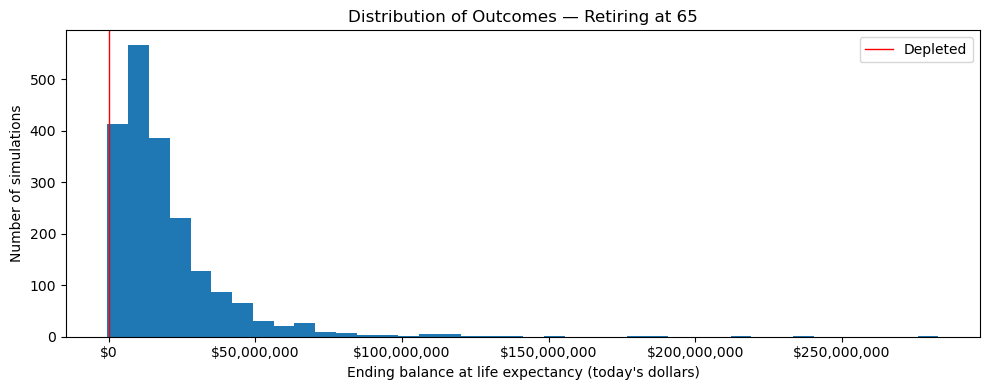

In [7]:
success_rate, ending_balances = monte_carlo_success(assumptions, assumptions["target_retirement_age"], n_sims=2000)

print(f"Retirement age tested: {assumptions['target_retirement_age']}")
print(f"Success rate (portfolio never depleted): {success_rate:.1%}")
print(f"Median ending balance: ${np.median(ending_balances):,.0f}")
print(f"10th percentile ending balance: ${np.percentile(ending_balances, 10):,.0f}")
print(f"90th percentile ending balance: ${np.percentile(ending_balances, 90):,.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ending_balances, bins=40)
ax.axvline(0, color="red", linewidth=1, label="Depleted")
ax.set_xlabel("Ending balance at life expectancy (today's dollars)")
ax.set_ylabel("Number of simulations")
ax.set_title(f"Distribution of Outcomes — Retiring at {assumptions['target_retirement_age']}")
ax.xaxis.set_major_formatter(lambda x, _: f"${x:,.0f}")
ax.legend()
plt.tight_layout()
plt.show()


### Success probability across a range of retirement ages

This sweeps the Monte Carlo simulation across several retirement ages so
you can see the trade-off between retiring earlier vs. later. A common
target is a 80-90%+ success rate.


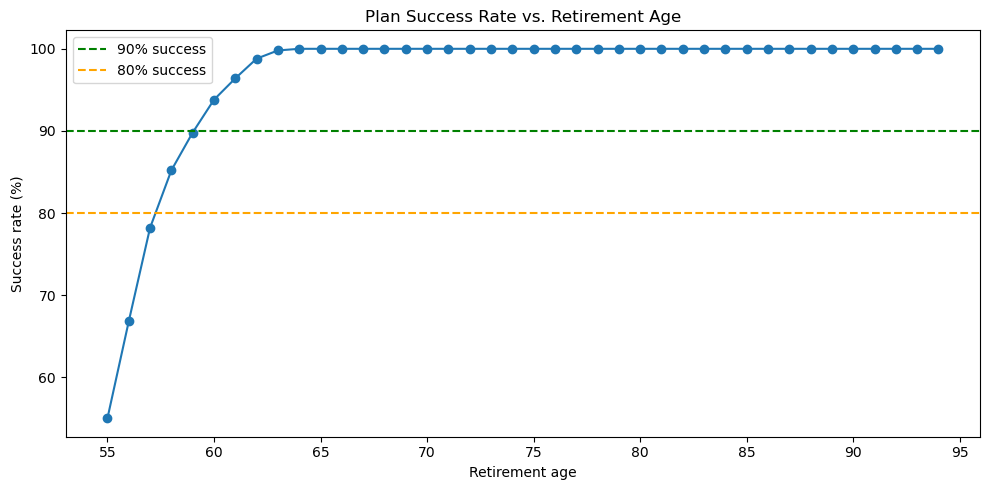

,retirement_age,success_rate
0,55,1
1,56,1
2,57,1
3,58,1
4,59,1
5,60,1
6,61,1
7,62,1
8,63,1
9,64,1


In [8]:
ages_to_test = range(55, assumptions["life_expectancy"], 1)
results = []

for age in ages_to_test:
    rate, _ = monte_carlo_success(assumptions, age, n_sims=500, seed=42)
    results.append({"retirement_age": age, "success_rate": rate})

mc_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mc_df["retirement_age"], mc_df["success_rate"] * 100, marker="o")
ax.axhline(90, color="green", linestyle="--", label="90% success")
ax.axhline(80, color="orange", linestyle="--", label="80% success")
ax.set_xlabel("Retirement age")
ax.set_ylabel("Success rate (%)")
ax.set_title("Plan Success Rate vs. Retirement Age")
ax.legend()
plt.tight_layout()
plt.show()

mc_df


## 5. Notes & Caveats

This model is intentionally simple so you can read, trust, and extend every
line of it. Things it does **not** account for that you may want to add:

- **Taxes.** Withdrawals from traditional 401(k)/IRA accounts are taxable;
  Roth withdrawals generally aren't. This model treats `annual_expenses` as
  the amount you need *after* tax. For a more accurate picture, separate
  your accounts by tax treatment and model withdrawals/taxes per account.
- **Multiple accounts with different growth rates.** Currently all savings
  are lumped into one balance with one return. You could extend
  `project_portfolio` to track several buckets (e.g. taxable, traditional,
  Roth) with different return assumptions and a withdrawal order.
- **Healthcare costs and Medicare.** Healthcare spending often rises faster
  than general inflation, especially before Medicare eligibility (65).
  Consider modeling a separate, higher-growth expense category.
- **Variable spending in retirement.** Many retirees spend more in early
  "go-go" years and less later. You could make `annual_expenses` a function
  of age instead of a constant.
- **Sequence-of-returns risk near retirement** is partially captured by the
  Monte Carlo simulation, but you could weight early-retirement years more
  heavily or use historical bootstrap sampling instead of a normal
  distribution for more realistic "fat tails."
- **One-time events** (downsizing a home, inheritance, large purchases) can
  be added as one-off adjustments to `balance` in specific years.

### Suggested next steps

- Try changing `target_retirement_age` and re-running sections 2-4 to
  compare scenarios side by side.
- Adjust `return_volatility` up or down to see how sensitive your plan is
  to market risk.
- Save copies of this notebook with different assumption sets (e.g.
  `retirement_plan_conservative.ipynb`, `retirement_plan_optimistic.ipynb`)
  to compare scenarios over time.
